In [1]:
import pandas as pd

### Basic Information and Dataset Loading

In [6]:
# Load dataset
df = pd.read_csv("data/student_habits_performance.csv")

In [7]:
# Initial peek at the information
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
# Inspect data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [9]:
# Inspect shape to see total records and features/target (cols/row)
df.shape

(1000, 16)

### EDA

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### Null/Missing Values

In [13]:
# Missing Values - use sum() to avoid seeing boolean return values as isna() does
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [18]:
# Quick inspection of the categorical column with the NA values
df[["parental_education_level"]].value_counts(dropna=False)

parental_education_level
High School                 392
Bachelor                    350
Master                      167
nan                          91
Name: count, dtype: int64

In [ ]:
# Dropping null values rows -> other approach: Fill with a categorical value such as 'none' instead of removing the rows altogether, this will be tested later on on model perf/accuracy.
df = df.dropna()
df.shape # 909 records remain now, matching the removed rows with NA for 'parental_education_level' categorical column.

(909, 16)

#### Duplicate Values checking

In [22]:
print(f"Sum of duplicated values in the dataset's rows: {df.duplicated().sum()}") # No action needed, no duplicate values in DF

Sum of duplicated values in the dataset's rows: 0


#### Basic Statistical Analysis

In [25]:
# Just for numerical values
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [27]:
# ... and for categorical columns
df.describe(include=["object", "str"])

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1000,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [29]:
# Value counts for categorical columns
categorical_columns = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

In [30]:
# See value counts
for col in categorical_columns:
    print(f"Value counts for column {col} \n {df[col].value_counts()}")

Value counts for column gender 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for column part_time_job 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for column diet_quality 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for column parental_education_level 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for column internet_quality 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for column extracurricular_participation 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


#### Univariate Analysis

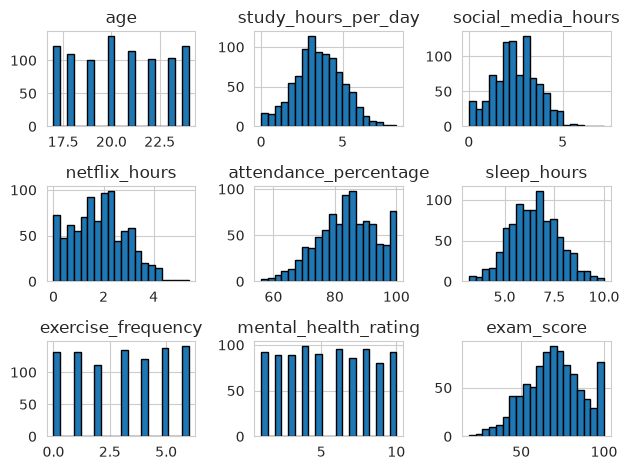

In [ ]:
# Histogram for the NUMERICAL VALUES
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

Exam score target variable displays a bit of skeweness, that being said, the distribution is almost like a _normal distribution_ in shape, if we don't include the 100s.

We can do now **count plots for categorical columns**

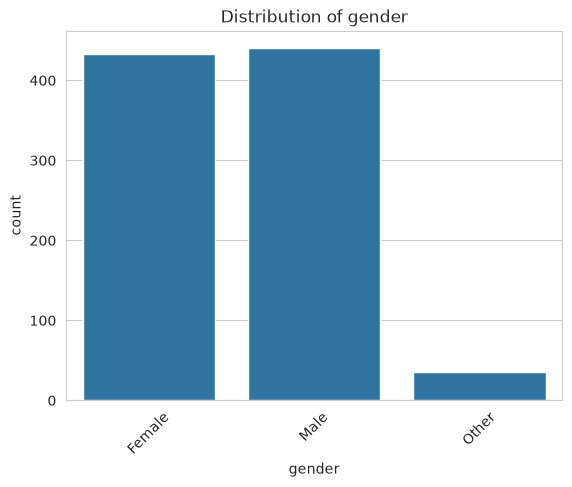

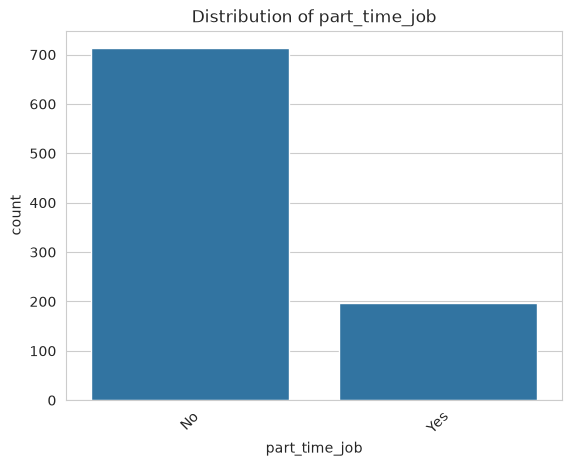

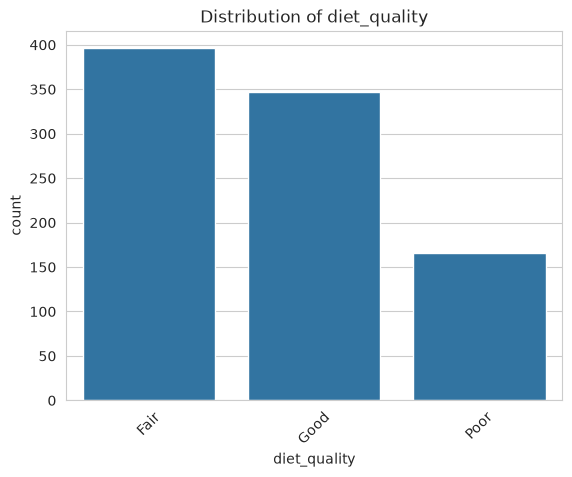

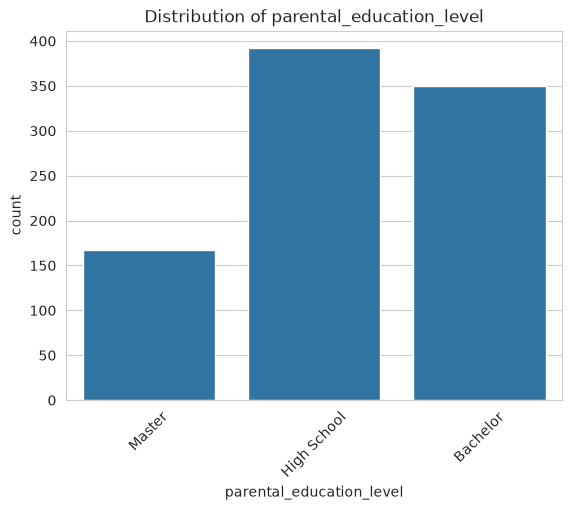

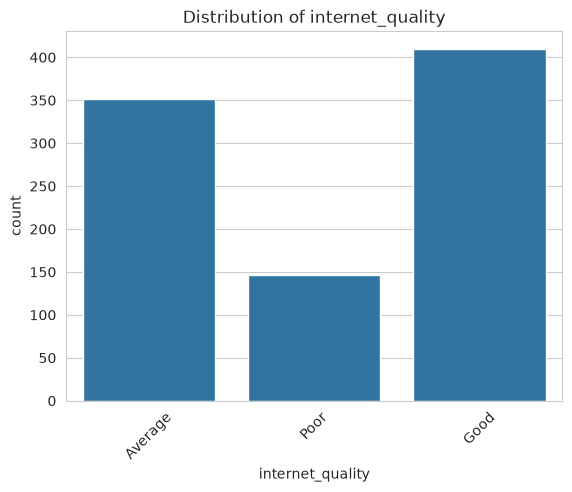

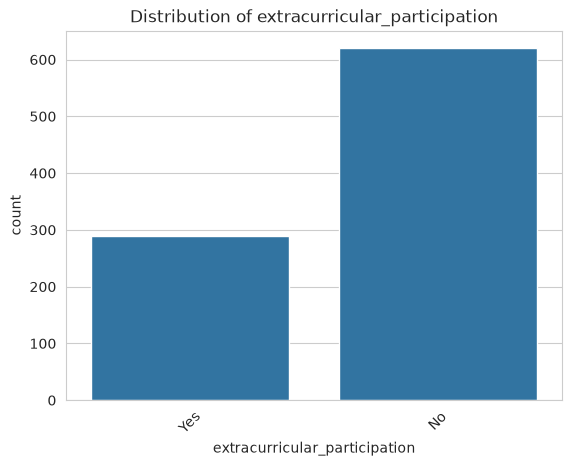

In [33]:
# Count Plots for categorical values
for col in categorical_columns:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### Correlation Matrix

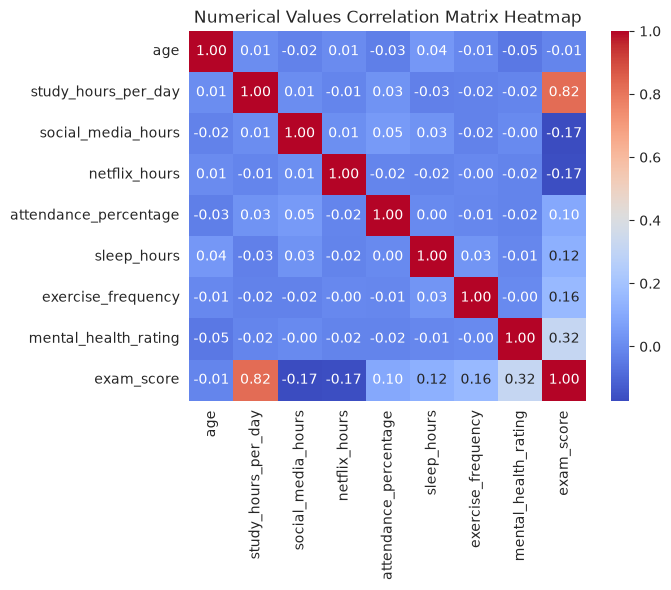

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Values Correlation Matrix Heatmap")
plt.show()

The **strongest or most notable correlation (pearson by default) is on the exam_score (y) and feature study_hours_per_day**

#### Bivariate Analysis

In [42]:
numerical_features = df.drop(columns="student_id").describe().columns
print(numerical_features)

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='str')


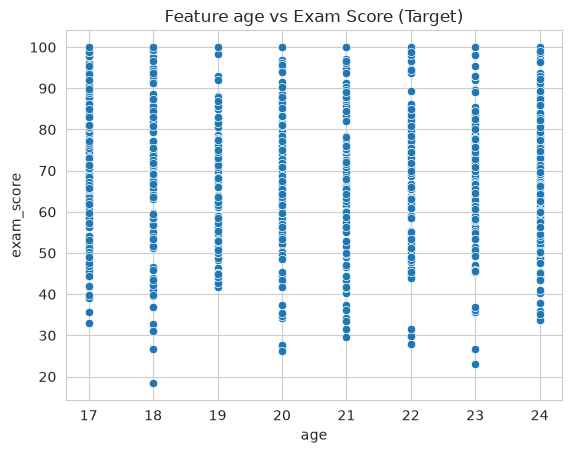

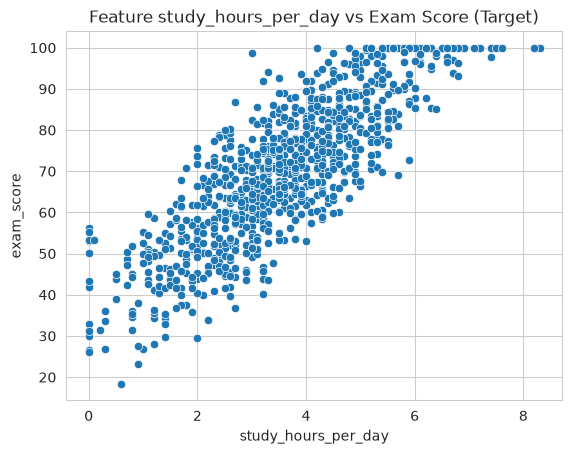

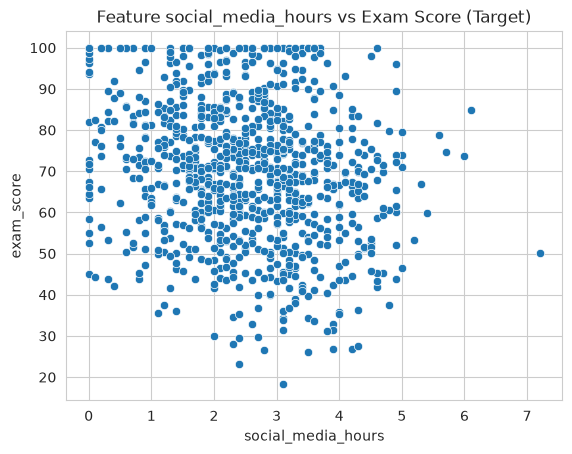

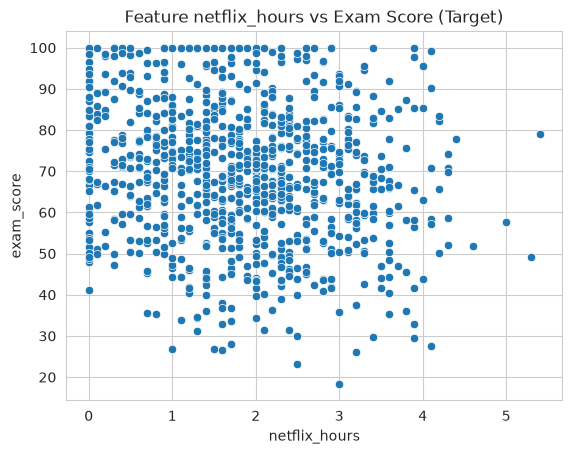

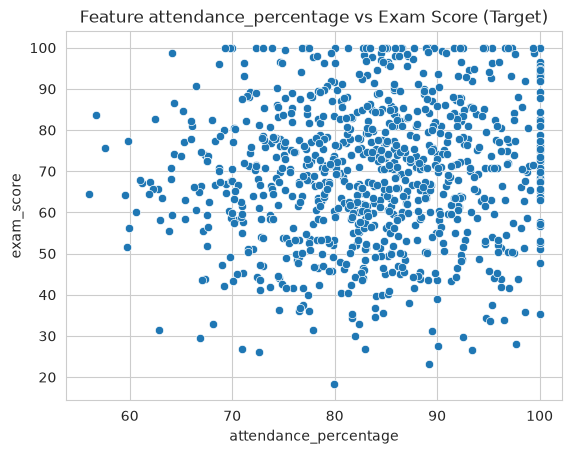

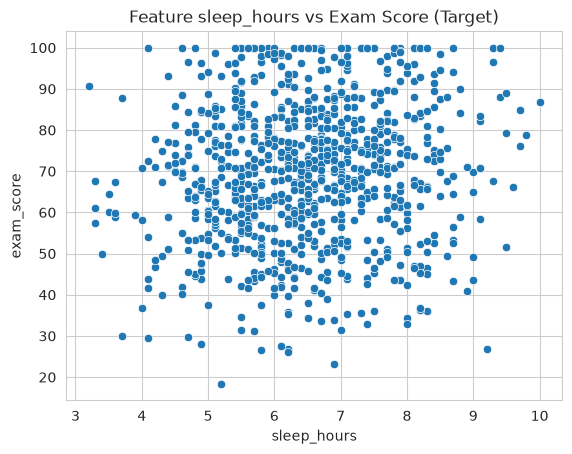

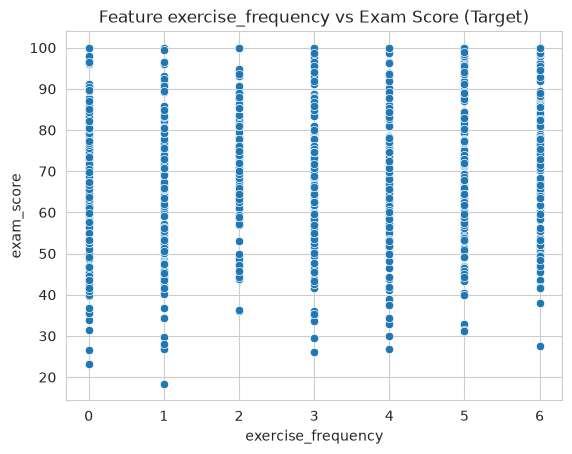

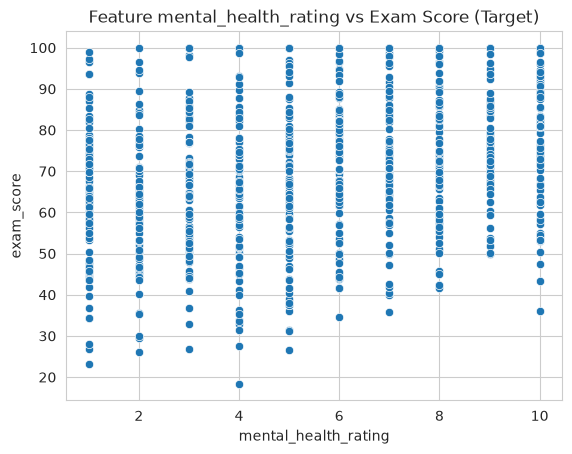

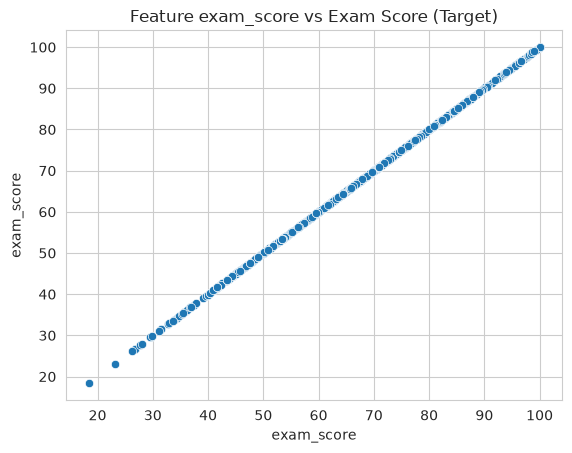

In [43]:
for feature in numerical_features:
    sns.scatterplot(data=df, x = feature, y = "exam_score")
    plt.title(f"Feature {feature} vs Exam Score (Target)")
    plt.show()

This **highlights again the correlation from the previous matrix between the feature 'study_hours' and the target variable**

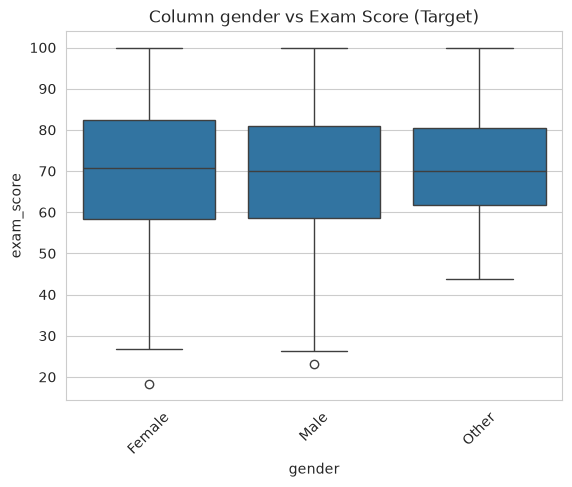

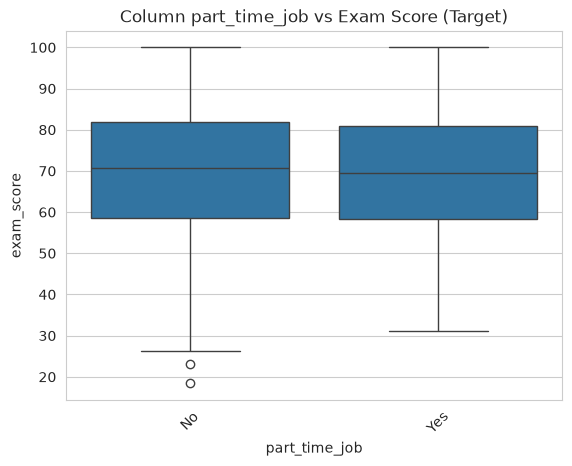

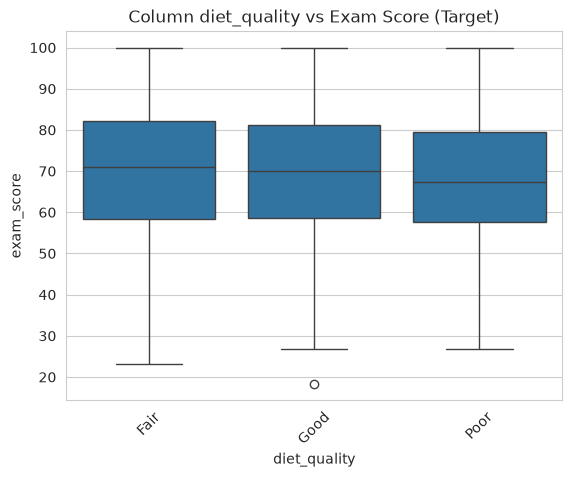

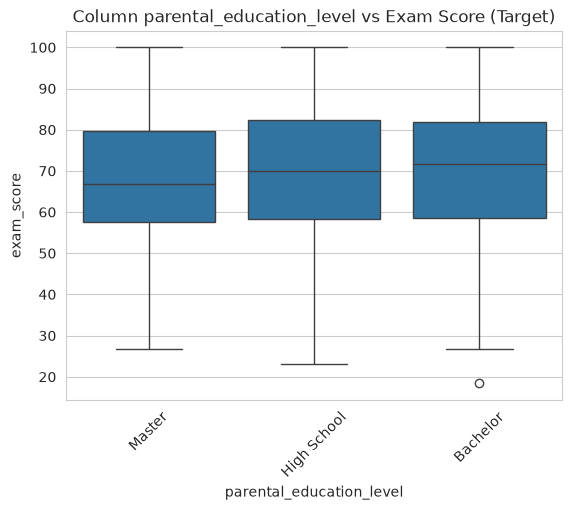

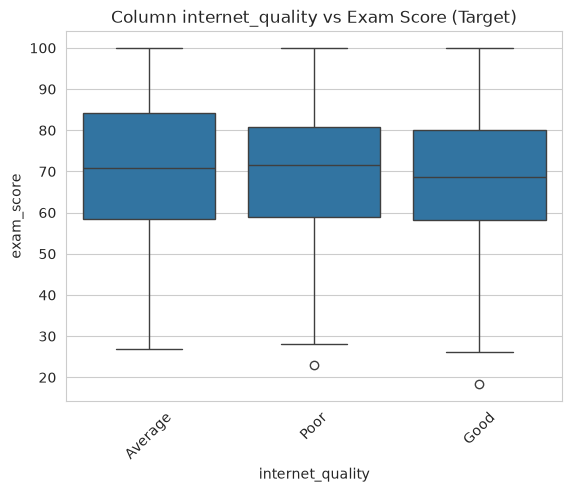

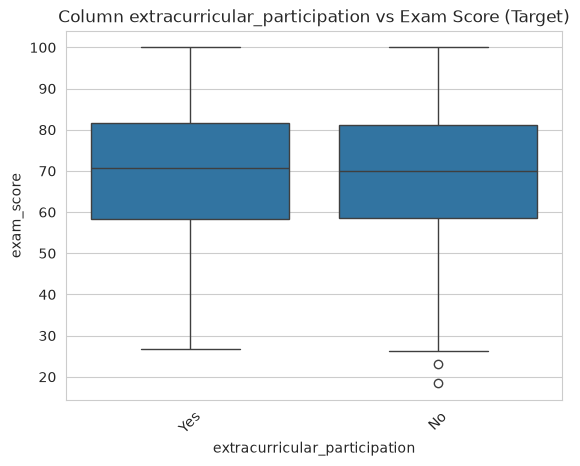

In [45]:
# Also plot BoxPlots for the categorical ones
for col in categorical_columns:
    sns.boxplot(data=df, x = col, y = "exam_score")
    plt.title(f"Column {col} vs Exam Score (Target)")
    plt.xticks(rotation=45)
    plt.show()

### Feature Engineering and Model Training

In [46]:
# Imports needed
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [48]:
# Constrain for now the features we suspect might yield a better prediction (this can be an iterative process based on EDA and a more profound EDA analysis)
features = ["study_hours_per_day", "attendance_percentage", "mental_health_rating", "sleep_hours", "part_time_job"]
# Set the target variable as exam_score
target = "exam_score"

In [49]:
df_model = df[features + [target]].copy()

In [50]:
# Peek at the df used for the model -iteration V0-
df_model.head()

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4


##### Features Encoding

As seen in the output above, part_time_job feature is categorical (bi-value), so we can encode into numerical values

In [ ]:
# LabelEncoder assigns from 0 onwards to labels/categories, here it will do No = 0 and Yes = 1, as it works in alphabetical order
le = LabelEncoder()